# Minimum safety factor
Use the **Python (FAITH labelmaker)** kernel. Change `shot` and `source` below.
Labels use 50 ms bins and 20 rho bins: gray = 0, white = unknown.


In [ ]:
from labeler.events.notebooks import load_shot, plot_shot

shot = 191515
source = "extend_qmin_rule/recommender_v1"
grid = load_shot("minimum_safety_factor", shot, source=source)
grid["categories"]

### Original labels
Original `qmin_rule` intervals before 50 ms binning. These are rule outputs, not raw q-min measurements.

In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt

from labeler.config import Paths
from labeler.events.schema import read_events

event, shot = grid["event"], grid["shot"]
root = Paths.from_env().label_tables
folder = root / event / source
meta = json.loads(folder.with_suffix(".meta.json").read_text())
events_root = Path(meta["full_events_root"])
if not events_root.is_absolute():
    events_root = Paths.from_env().root / events_root
path = events_root / f"{shot}_events.parquet"
if not path.is_file():
    print(f"Original rule output is unavailable: {path}")
else:
    rows = read_events(path)
    rows = rows.loc[(rows.shot == shot) & (rows.source == meta["producer"])]
    bands = [
        (name, name.removeprefix("qmin_"))
        for name in ["qmin_low", "qmin_hybrid", "qmin_elevated", "qmin_high"]
    ]
    fig, ax = plt.subplots(figsize=(10, 3.5), layout="constrained")
    for i, (name, _) in enumerate(bands):
        selected = rows.loc[rows.phenomenon == name]
        ax.broken_barh(
            [
                (r.t0_s * 1000, (r.t1_s - r.t0_s) * 1000)
                for r in selected.itertuples()
            ],
            (i - 0.35, 0.7),
        )
    ax.set(
        yticks=range(len(bands)),
        yticklabels=[name for _, name in bands],
        xlabel="Time (ms)",
        ylabel="Original rule category",
        title=f"Shot {shot} — original qmin_rule intervals (before 50 ms binning)",
    )
    plt.show()

### Formatted labels
The saved grid uses 50 ms bins, with each label broadcast over 20 rho bins.

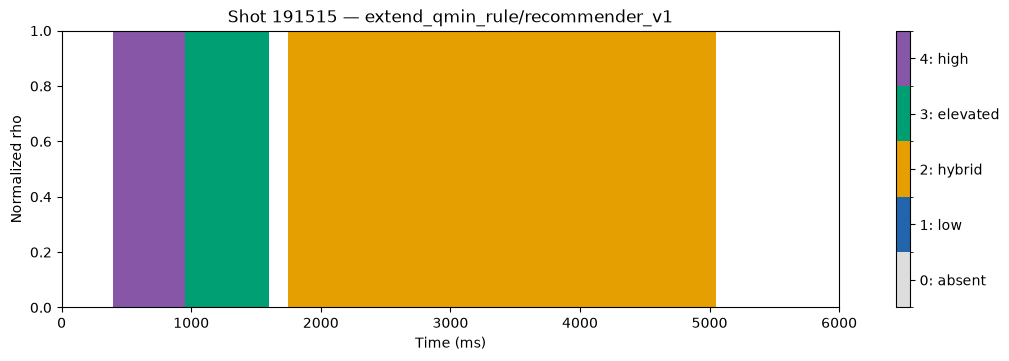

In [3]:
plot_shot(grid);

Available extended source: `extend_qmin_rule/recommender_v1`. The same loader and plot work for formatted and extended files.